# Multi-shot Partial-Fourier Fat-Sat SE Diffusion EPI

This notebook designs a new multi-shot spin-echo diffusion EPI sequence by borrowing the structure from the existing test demo.

## Outline
1. Import sequence modules and utilities.
2. Define imaging, diffusion, and shot parameters.
3. Build system limits and reusable RF/FatSat blocks.
4. Load or synthesize diffusion waveforms.
5. Generate diffusion direction set.
6. Build segmented EPI readouts (multi-shot + partial Fourier).
7. Assemble the full sequence with TE/TR balancing and labels.
8. Run timing QA and visualize a small temporal window.
9. Export a .seq file for scanner execution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import pypulseq as pp
from pSeq import pSeq_Base, pSeq_EPI_base, pSeq_FatSat, pSeq_RF, pSeq_Diffusion, pSeq_GRE_multi_echo

import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

In [2]:
# ------------------------------
# User-facing protocol parameters
# ------------------------------
fov = 220e-3
# nx = 96
# ny = 96
nx = 128
ny = 128
partial_fourier = 0.75          # Keep 75% of ky lines
n_shots = 1                     # EPI segmentation factor
readout_time = 0.59e-3

# Ghost navigator controls
enable_ghost_nav = True
ghost_nav_lines = 3             # Repeated center-line echoes (RO-only) per shot

# Multi-slice controls
n_slices = 5
slice_thickness = 5e-3
slice_gap = 20e-3

num_repeats = 2
TR_sec = 1.20
b_value = 2000

# Symmetric slice positions around isocenter (in meters)
slice_offsets = (np.arange(n_slices) - (n_slices - 1) / 2.0) * (slice_thickness + slice_gap)

print(f"FOV={fov*1e3:.1f} mm, Matrix={nx}x{ny}, PF={partial_fourier}, Shots={n_shots}")
print(f"Ghost nav enabled={enable_ghost_nav}, lines={ghost_nav_lines}")
print(f"Slices={n_slices}, slice_thickness={slice_thickness*1e3:.1f} mm, gap={slice_gap*1e3:.1f} mm")
print(f"Directions={7} (b0 + 6 axes), Repeats={num_repeats}, TR={TR_sec*1e3:.0f} ms")

FOV=220.0 mm, Matrix=128x128, PF=0.75, Shots=1
Ghost nav enabled=True, lines=3
Slices=5, slice_thickness=5.0 mm, gap=20.0 mm
Directions=7 (b0 + 6 axes), Repeats=2, TR=1200 ms


In [3]:
# --------------------------------------------------------
# Build hardware limits and reusable preparation/readout blocks
# --------------------------------------------------------
system_max = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=200, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_diff = pp.Opts(
    max_grad=160, grad_unit='mT/m',
    max_slew=40, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_epi = pp.Opts(
    max_grad=80, grad_unit='mT/m',
    max_slew=160, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_low = pp.Opts(
    max_grad=30, grad_unit='mT/m',
    max_slew=30, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_ms = pSeq_Base(system=system_max)

# Fat saturation block
fatsat = pSeq_FatSat(system=system_low, type='FatSat2')
fatsat.prep_fatsat()

# 90-degree excitation
rf90 = pSeq_RF(
    system=system_max, flip_angle=np.pi/2, duration=3e-3,
    thickness=5e-3, use='excitation'
)
rf90.prep()

# 180-degree refocusing with crushers
rf180 = pSeq_RF(
    system=system_low, flip_angle=np.pi, duration=6e-3,
    thickness=5e-3, use='refocusing', do_refocus=False,
    crusher_area=100, crusher_axis=['x', 'y', 'z']
)
rf180.prep()

# External trigger before EPI readout (optional but useful for synchronization)
trig = pp.make_digital_output_pulse('ext1', duration=20e-6)

-220.3308
0.003 0.003
-220.3308
Fat Sat: The peak rf_fs Amplitude =  1.6253962983488777e-06 uT
Making Sinc Pulse with flip angle 90.0
Making SLR Pulse with flip angle 90.0
excitation : The peak rf Amplitude =  7.797889527969152 uT
Making Sinc Pulse with flip angle 180.0
Making SLR Pulse with flip angle 180.0
refocusing : The peak rf Amplitude =  7.797889596354154 uT
Prepared crusher gradients for refocusing pulse on ['x', 'y', 'z']-axis with area 100 1/m


In [4]:
# -------------------------------------------------------------
# Fixed diffusion direction set (b0 + 6 cardinal directions)
# -------------------------------------------------------------
diff_dirs = np.array([
    [ 0.0,  0.0,  0.0],  # b0 (no diffusion weighting)
    [ 1.0,  0.0,  0.0],  # x+
    [-1.0,  0.0,  0.0],  # x-
    [ 0.0,  1.0,  0.0],  # y+
    [ 0.0, -1.0,  0.0],  # y-
    [ 0.0,  0.0,  1.0],  # z+
    [ 0.0,  0.0, -1.0],  # z-
], dtype=float)

dir_labels = ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']
num_dirs = diff_dirs.shape[0]

import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=diff_dirs[:, 0],
            y=diff_dirs[:, 1],
            z=diff_dirs[:, 2],
            mode='markers+text',
            text=dir_labels,
            textposition='top center',
            marker=dict(
                size=5,
                color=np.arange(len(diff_dirs)),
                colorscale='Viridis',
                opacity=0.9
            ),
            name='diffusion directions'
        )
    ]
)

fig.update_layout(
    title='Diffusion direction table (b0 + 6 directions)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
print('Using diffusion directions:', dir_labels)

Using diffusion directions: ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']


In [5]:
# # -------------------------------------------------------------
# # Diffusion direction set: b0 + 32-direction fibonacci sphere
# # -------------------------------------------------------------
# def fibonacci_sphere(samples=32):
#     i = np.arange(samples, dtype=float) + 0.5
#     phi = np.arccos(1.0 - 2.0 * i / samples)
#     theta = np.pi * (1.0 + np.sqrt(5.0)) * i

#     x = np.cos(theta) * np.sin(phi)
#     y = np.sin(theta) * np.sin(phi)
#     z = np.cos(phi)
#     return np.column_stack((x, y, z))

# fib_dirs = fibonacci_sphere(32)
# diff_dirs = np.vstack((np.array([[0.0, 0.0, 0.0]], dtype=float), fib_dirs))

# dir_labels = ['b0'] + [f'd{idx:02d}' for idx in range(1, diff_dirs.shape[0])]
# num_dirs = diff_dirs.shape[0]

# import plotly.graph_objects as go

# fig = go.Figure(
#     data=[
#         go.Scatter3d(
#             x=diff_dirs[:, 0],
#             y=diff_dirs[:, 1],
#             z=diff_dirs[:, 2],
#             mode='markers+text',
#             text=dir_labels,
#             textposition='top center',
#             marker=dict(
#                 size=4,
#                 color=np.arange(len(diff_dirs)),
#                 colorscale='Viridis',
#                 opacity=0.9
#             ),
#             name='diffusion directions'
#         )
#     ]
# )

# fig.update_layout(
#     title='Diffusion direction table (b0 + fibonacci sphere N=32)',
#     scene=dict(
#         xaxis_title='X',
#         yaxis_title='Y',
#         zaxis_title='Z',
#         aspectmode='cube'
#     ),
#     margin=dict(l=0, r=0, b=0, t=40)
# )

# fig.show()
# print(f'Using diffusion directions: {num_dirs} total (1 b0 + 32 DWI)')

In [6]:
# ----------------------------------------------------------------------
# Build segmented EPI readouts: each shot uses a different Nmulti index
# while sharing RSegment (number of shots) and partial Fourier settings.
# ----------------------------------------------------------------------
epi_shots = []
for shot_idx in range(n_shots):
    epi = pSeq_EPI_base(
        system=system_epi,
        fov=fov,
        nx=nx,
        ny=ny,
        readoutTime=readout_time,
        R=1,
        RSegment=n_shots,
        Nmulti=shot_idx + 1,
        partFourierFactor=partial_fourier,
        ghost_lines=ghost_nav_lines,
    )
    epi.prep(ro_os=1, pe_enable=1)
    epi_shots.append(epi)


def compute_spin_echo_delays(epi_obj, rf90_obj, rf180_obj, diff_dur0, diff_dur1, system):
    """Compute raster-aligned delays so spin echo aligns with EPI center."""
    rf90_after = rf90_obj.get_duration() - rf90_obj.get_timing()[1]['center_incl_delay']
    rf180_center = rf180_obj.get_timing()[1]['center_incl_delay']
    rf180_after = rf180_obj.get_duration() - rf180_center

    epi_to_te = epi_obj.get_timeToTE()['timeToTE']

    left = rf90_after + diff_dur0 + rf180_center
    right = rf180_after + diff_dur1 + epi_to_te

    half_te = max(left, right)
    d1 = max(0.0, half_te - left)
    d2 = max(0.0, half_te - right)

    raster = system.grad_raster_time
    d1 = np.ceil(d1 / raster) * raster
    d2 = np.ceil(d2 / raster) * raster
    return d1, d2, 2 * half_te


print(f'Prepared {len(epi_shots)} EPI shot objects for segmented readout.')

EPI: Echo Spacing is  0.6500000000000001 ms
EPI: ADC Bandwidth =  370.3703703703704 kHz
Actual RO oversampling factor is   1.0040509259259258
EPI: ADC Samples are  216.0
Prepared 1 EPI shot objects for segmented readout.


In [7]:
# ---------------------------------------------------------------------
# Sequence assembly (multi-slice)
# Loop order: repeat -> slice -> diffusion direction -> shot
# ---------------------------------------------------------------------
# Reinitialize sequence so repeated execution of this cell is deterministic
seq_ms = pSeq_Base(system=system_max)

nav_duration_s = 0.0
if enable_ghost_nav and ghost_nav_lines > 0:
    nav_duration_s = epi_shots[0].get_timeToTE()['ghost_nav']
print(f'Pre-diffusion ghost-nav duration per shot: {nav_duration_s*1e3:.3f} ms')

# Design monopolar diffusion lobes directly from target b-value and timing constraints.
# If navigators are placed before the first diffusion lobe, include this delay in TE/b design.
diffusion = pSeq_Diffusion(
    system=system_diff,
    channel='x',
    target_b_s_mm2=b_value,
    max_lobe_duration=40e-3,
)
diff_summary = diffusion.prep_monopolar(
    rf90=rf90,
    rf180=rf180,
    epi=epi_shots[0],
    extra_pre_delay_s=nav_duration_s,
    verbose=True,
)

print('Estimated b-values from trapezoid designer:')
print(f'  b0  -> 0.00 s/mm^2')
print(f'  dwi -> {diffusion.b_actual_s_mm2:.2f} s/mm^2')
print('Spin-echo alignment check:')
print(f"  mismatch at EPI echo center: {diffusion.spin_echo_mismatch*1e6:.3f} us")

over_tr_count = 0
total_volumes = 0

for rep in range(num_repeats):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        # Set slice frequency/phase offsets so excitation and refocusing hit same slice
        rf90.offset_rf(offset=slc_offset)
        rf180.offset_rf(offset=slc_offset)

        for diff_dir_idx, diff_dir in enumerate(diff_dirs):
            for shot_idx, epi in enumerate(epi_shots):
                total_volumes += 1
                start_time = seq_ms.seq.duration()[0] if len(seq_ms.seq.block_events) > 0 else 0.0

                # Labels:
                # REP = repetition index
                # SLC = slice index
                # SEG = diffusion direction index
                # AVG = shot index
                lrep = pp.make_label(type='SET', label='REP', value=rep)
                lslc = pp.make_label(type='SET', label='SLC', value=slc_idx)
                lseg = pp.make_label(type='SET', label='SEG', value=diff_dir_idx)
                lavg = pp.make_label(type='SET', label='AVG', value=shot_idx)
                seq_ms.seq.add_block(lrep, lslc, lseg, lavg, trig)

                # b0 has zero direction, so apply matched delays instead of gradients
                g0, g1 = diffusion.get_rotated_lobes(diff_dir)

                # Core SE diffusion module with optional pre-diffusion ghost navigator
                seq_ms.add_pseq_to_self(fatsat)
                seq_ms.add_pseq_to_self(rf90)

                if enable_ghost_nav and ghost_nav_lines > 0:
                    epi.add_to_seq(seq_ms, ghost_nav=True, label=True)

                seq_ms.seq.add_block(*g0)

                if diffusion.delay1 > 0:
                    seq_ms.seq.add_block(pp.make_delay(diffusion.delay1))

                seq_ms.add_pseq_to_self(rf180)

                seq_ms.seq.add_block(*g1)

                if diffusion.delay2 > 0:
                    seq_ms.seq.add_block(pp.make_delay(diffusion.delay2))

                # Trigger + segmented EPI readout
                seq_ms.add_pseq_to_self(epi)

                # TR fill so each shot has a fixed duration
                end_time = seq_ms.seq.duration()[0]
                shot_dur = end_time - start_time
                tr_pad = TR_sec - shot_dur

                if tr_pad > system_max.grad_raster_time:
                    tr_pad = np.ceil(tr_pad / system_max.grad_raster_time) * system_max.grad_raster_time
                    seq_ms.seq.add_block(pp.make_delay(tr_pad))
                elif tr_pad < -1e-6:
                    over_tr_count += 1

print(f'Estimated sequence duration: {seq_ms.seq.duration()[0]:.2f} s')
print(f'Total shot blocks added: {total_volumes}')
print(f'TR violations (negative TR padding): {over_tr_count}')
print(f'Designed diffusion TE(min): {diffusion.te*1e3:.2f} ms')

Pre-diffusion ghost-nav duration per shot: 2.790 ms
Diffusion designer summary:
  target b: 2000.00 s/mm^2
  actual b: 2000.00 s/mm^2
  lobe amplitude: 6801068.268 Hz/m
  lobe duration: 9.940 ms
  delay1: 16.130 ms
  delay2: 0.000 ms
  pre-lobe delay: 4.769 ms
  inter-lobe delay: 23.470 ms
  TE(min): 69.020 ms
  spin-echo mismatch: 6.000 us
Estimated b-values from trapezoid designer:
  b0  -> 0.00 s/mm^2
  dwi -> 2000.00 s/mm^2
Spin-echo alignment check:
  mismatch at EPI echo center: 6.000 us
Estimated sequence duration: 84.00 s
Total shot blocks added: 70
TR violations (negative TR padding): 0
Designed diffusion TE(min): 69.02 ms


Timing check passed: True
Total sequence duration: 84.000 s


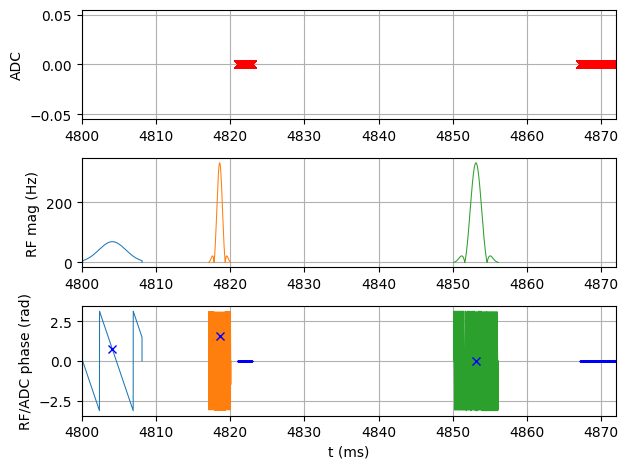

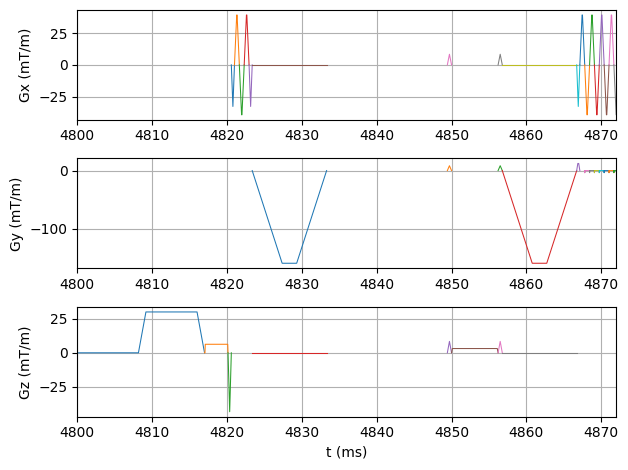

In [8]:
# ---------------------------------------
# Timing QA and quick visual inspection
# ---------------------------------------
ok, err = seq_ms.seq.check_timing()
print(f'Timing check passed: {ok}')
if not ok:
    print('First timing issues:')
    for item in err[:10]:
        print(' -', item)

total_time = seq_ms.seq.duration()[0]
print(f'Total sequence duration: {total_time:.3f} s')

# Plot a short window near sequence start for readability
seq_ms.seq.plot(time_range=[TR_sec*4, TR_sec*4.06], grad_disp='mT/m', time_disp='ms')
plt.show()

## Multi-shot trajectory and echo/sample distribution

This section visualizes how ADC samples are distributed across shots and where each shot echo center lands in time.

- `k_traj_adc`: sampled trajectory points (ADC on)
- `k_traj`: continuous trajectory
- `t_adc`: ADC sample times
- Echo centers are approximated as the temporal center of each shot's ADC window for one volume

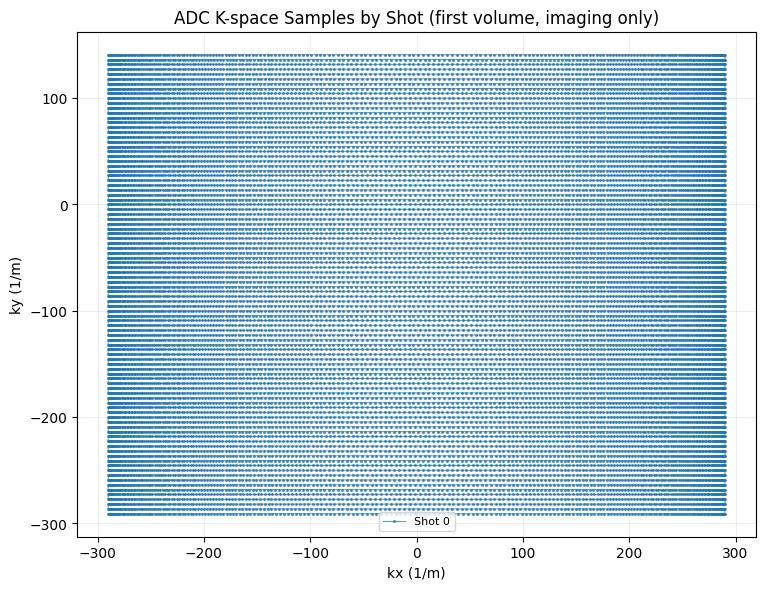

Trajectory summary (first volume):
  ADC samples / echo: 216
  Navigator echoes / shot: 3
  Imaging echoes / shot: 96
  Samples / shot (nav + img): 21384 (648 + 20736)
  Samples / volume: 21384
  Echo center times [ms]: [98.31]


In [9]:
# Compute full trajectory from the assembled sequence
k_traj_adc, k_traj, t_excitation, t_refocusing, t_adc = seq_ms.seq.calculate_kspace()

# Derive shot-wise sample geometry from the segmented EPI object
adc_samples_per_echo = int(epi_shots[0].adc_samples)
echoes_per_shot = int(epi_shots[0].Ny_meas)
nav_echoes_per_shot = int(ghost_nav_lines if enable_ghost_nav else 0)

samples_per_shot_img = adc_samples_per_echo * echoes_per_shot
samples_per_shot_nav = adc_samples_per_echo * nav_echoes_per_shot
samples_per_shot_total = samples_per_shot_nav + samples_per_shot_img
samples_per_volume = samples_per_shot_total * n_shots

if k_traj_adc.shape[1] < samples_per_volume:
    raise RuntimeError('Not enough ADC samples for one full volume. Check sequence assembly.')

# Inspect one volume only (first table row, rep 0), which is first in assembly order
k_adc_vol = k_traj_adc[:, :samples_per_volume]
t_adc_vol = t_adc[:samples_per_volume]

# Split into shots for clean visualization
k_adc_by_shot = []
t_adc_by_shot = []
echo_time_centers = []
for s in range(n_shots):
    i0 = s * samples_per_shot_total
    i1 = (s + 1) * samples_per_shot_total

    k_s_all = k_adc_vol[:, i0:i1]
    t_s_all = t_adc_vol[i0:i1]

    if samples_per_shot_nav > 0:
        k_s = k_s_all[:, samples_per_shot_nav:]
        t_s = t_s_all[samples_per_shot_nav:]
    else:
        k_s = k_s_all
        t_s = t_s_all

    k_adc_by_shot.append(k_s)
    t_adc_by_shot.append(t_s)

    # Echo center approximation: center sample of each shot's imaging ADC window
    echo_time_centers.append(0.5 * (t_s[0] + t_s[-1]))

echo_time_centers = np.array(echo_time_centers)

# 1) K-space distribution by shot (imaging lines only; nav excluded)
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

for s, k_s in enumerate(k_adc_by_shot):
    axes.plot(k_s[0, :], k_s[1, :], '-o', ms=1.2, alpha=0.7, label=f'Shot {s}')

axes.set_title('ADC K-space Samples by Shot (first volume, imaging only)')
axes.set_xlabel('kx (1/m)')
axes.set_ylabel('ky (1/m)')
axes.set_aspect('equal', adjustable='box')
axes.grid(True, alpha=0.2)
axes.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

print('Trajectory summary (first volume):')
print(f'  ADC samples / echo: {adc_samples_per_echo}')
print(f'  Navigator echoes / shot: {nav_echoes_per_shot}')
print(f'  Imaging echoes / shot: {echoes_per_shot}')
print(f'  Samples / shot (nav + img): {samples_per_shot_total} ({samples_per_shot_nav} + {samples_per_shot_img})')
print(f'  Samples / volume: {samples_per_volume}')
print(f'  Echo center times [ms]: {np.round(echo_time_centers * 1e3, 3)}')

In [10]:
# -----------------------------
# Export sequence to .seq file
# -----------------------------
version = 'v0.1.6'
out_dir = Path('seq')
out_dir.mkdir(parents=True, exist_ok=True)
nav_tag = f'_nav{ghost_nav_lines}' if enable_ghost_nav else '_nav0'
out_name = f'fs_se_dti_b{int(b_value)}_dir{len(diff_dirs)}_pf{int(partial_fourier*100)}_shot{n_shots}_slice{n_slices}{nav_tag}_{version}.seq'
out_path = out_dir / out_name

# seq_ms.seq.write(str(out_path))
print(f'Wrote sequence: {out_path}')

# Optional safety check (requires local ASC file):
# seq_ms.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, seq_ms.seq.duration()[0]], cns=True, do_plot=False)
# seq_ms.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, TR_sec], cns=True, do_plot=True)

Wrote sequence: seq\fs_se_dti_b2000_dir7_pf75_shot1_slice5_nav3_v0.1.6.seq


In [11]:
# ------------------------------------------------------------------
# Multi-echo FLASH (GRE) sensitivity mapping sequence (new pSeq_Base)
# Geometry is matched to diffusion EPI: FOV, in-plane matrix, slices.
# ------------------------------------------------------------------
system_gre = pp.Opts(
    max_grad=120, grad_unit='mT/m',
    max_slew=60, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_meflash = pSeq_Base(system=system_gre)
seq_meflash.init_seq()

gre_sens = pSeq_GRE_multi_echo(
    system=system_gre,
    fov=fov,
    nx=nx,
    ny=ny,
    slice_thickness=slice_thickness,
    flip_angle=np.deg2rad(5.0),
    rf_duration=0.8e-3,
    readout_time=1.28e-3,
    te1=2.7e-3,
    echo_spacing=3.3e-3,
    tr=20e-3,
    n_echoes=4,
    readout_mode='monopolar',
    rf_spoil_inc_deg=117.0,
    spoiler_area_ro=6.0 / 1e-3,
    spoiler_area_pe=6.0 / 1e-3,
    spoiler_area_sl=8.0 / 1e-3,
 )
gre_sens.prep()

for rep_idx in range(1):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        for lin_idx in range(ny):
            gre_sens.add_line_to_seq(
                seq_meflash,
                line_index=lin_idx,
                slice_offset=slc_offset,
                rep_idx=rep_idx,
                slc_idx=slc_idx,
                label=True,
            )

ok_me, err_me = seq_meflash.seq.check_timing()
print(f'ME-FLASH timing check passed: {ok_me}')
if not ok_me:
    print('First timing issues:')
    for item in err_me[:10]:
        print(' -', item)

me_timing = gre_sens.get_timing()
print(f"ME-FLASH nominal TR: {me_timing['tr_nominal']*1e3:.3f} ms")
print(f"TEs [ms]: {np.round((me_timing['te1'] + np.arange(me_timing['n_echoes']) * me_timing['echo_spacing']) * 1e3, 3)}")


Prepared multi-echo FLASH blocks:
  Matrix: 128x128, FOV: 220.0 mm
  Readout mode: monopolar
  Inter-echo rewind (constrained): 1.660 ms
  Inter-echo delay block: 0.000 ms
  Echoes: 4, TE1: 2.70 ms, dTE: 3.30 ms
  TR: 20.00 ms, TR fill: 1.52 ms
ME-FLASH timing check passed: True
ME-FLASH nominal TR: 20.010 ms
TEs [ms]: [ 2.7  6.   9.3 12.6]


Wrote ME-FLASH sequence: seq\meflash_sens_fov220_mat128x128_slc5_thk5_echo4_v0.1.1.seq
PNS is OK
CNS is OK


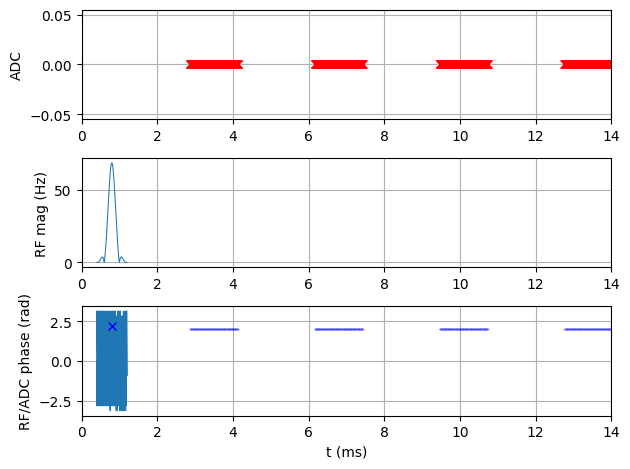

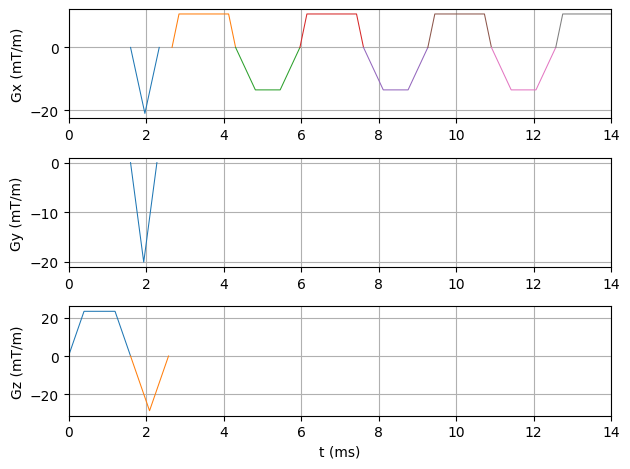

In [12]:
meflash_version = 'v0.1.1'
meflash_out_dir = Path('seq')
meflash_out_dir.mkdir(parents=True, exist_ok=True)
meflash_name = (
    f'meflash_sens_fov{int(fov*1e3)}_'
    f'mat{nx}x{ny}_slc{n_slices}_thk{int(slice_thickness*1e3)}_'
    f'echo{me_timing["n_echoes"]}_{meflash_version}.seq'
 )
meflash_path = meflash_out_dir / meflash_name
# seq_meflash.seq.write(str(meflash_path))
print(f'Wrote ME-FLASH sequence: {meflash_path}')

seq_meflash.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, 14e-3], cns=True, do_plot=False)
seq_meflash.seq.plot(time_disp='ms', grad_disp='mT/m', time_range=[0, 14e-3])

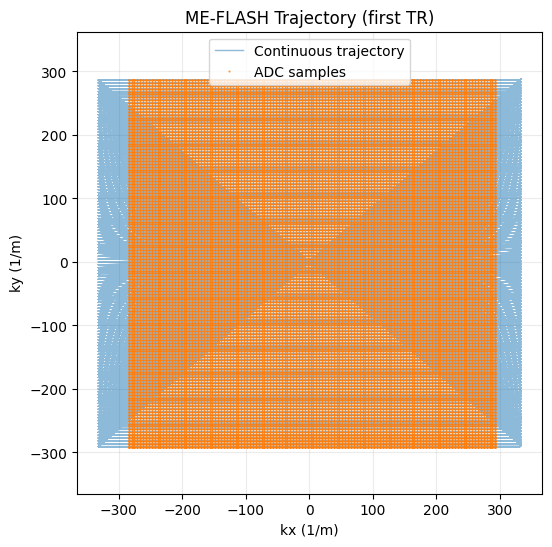

In [13]:
# Plot ME-FLASH k-space trajectory (continuous + ADC samples)

k_adc_me, k_me, t_exc_me, t_ref_me, t_adc_me = seq_meflash.seq.calculate_kspace()

# Show one TR for readability
tr_me = me_timing['tr_nominal'] if 'me_timing' in globals() else 20e-3
t0 = 0.0
t1 = t0 + tr_me * ny

k_me_2d = k_me[:2, :]
k_adc_me_2d = k_adc_me[:2, :]

mask_cont = (k_me[2, :] >= t0) & (k_me[2, :] <= t1)
mask_adc = (t_adc_me >= t0) & (t_adc_me <= t1)

plt.figure(figsize=(6, 6))
plt.plot(k_me_2d[0, mask_cont], k_me_2d[1, mask_cont], '-', lw=1.0, alpha=0.5, label='Continuous trajectory')
plt.plot(k_adc_me_2d[0, mask_adc], k_adc_me_2d[1, mask_adc], '.', ms=1.1, alpha=0.8, label='ADC samples')

plt.title('ME-FLASH Trajectory (first TR)')
plt.xlabel('kx (1/m)')
plt.ylabel('ky (1/m)')
plt.axis('equal')
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

In [29]:
# ---------------------------------------------------------------
# B0 workflow: load/reformat b0 TWIX, estimate coil sensitivity,
# reconstruct multi-echo images, and compute slice-wise B0 map.
# ---------------------------------------------------------------
from scipy.fft import fftshift, ifftshift, ifft2
import sigpy as sp
from sigpy.mri.app import EspiritCalib

def _ifftc2_local(ksp):
    return fftshift(ifft2(ifftshift(ksp, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))

def _safe_get_twix_image_obj(mapped_obj):
    if isinstance(mapped_obj, list) and len(mapped_obj) > 0:
        mapped_obj = mapped_obj[-1]
    if isinstance(mapped_obj, dict) and 'image' in mapped_obj:
        return mapped_obj['image']
    raise RuntimeError('Mapped twix object does not contain a readable image block.')

def _safe_get_twix_image(mapped_obj):
    img_obj = _safe_get_twix_image_obj(mapped_obj)
    try:
        return np.asarray(img_obj[:]).squeeze()
    except Exception as exc:
        raise RuntimeError(f'Failed to read image block from mapped twix object: {exc}') from exc

def _infer_axes_from_twix_dims(img_obj, squeezed_shape, role_candidates):
    """Infer squeezed-array axis indices from map_twix dim labels.

    img_obj.dims is typically:
      ('Ide','Idd','Idc','Idb','Ida','Seg','Set','Rep','Phs','Eco','Par','Sli','Ave','Lin','Cha','Col')
    while np.asarray(img_obj[:]).squeeze() keeps only non-singleton dims in this order.
    """
    dims = tuple(getattr(img_obj, 'dims', ()))
    full_shape = tuple(getattr(img_obj, 'shape', ()))
    if len(dims) == 0 or len(full_shape) != len(dims):
        return None

    non_singleton_dims = [d for d, s in zip(dims, full_shape) if int(s) > 1]
    if len(non_singleton_dims) != len(squeezed_shape):
        return None

    dim_to_axis = {d: i for i, d in enumerate(non_singleton_dims)}
    axis_map = {}
    for role, cand_dims in role_candidates.items():
        hit = None
        for d in cand_dims:
            if d in dim_to_axis:
                hit = dim_to_axis[d]
                break
        if hit is None:
            return None
        axis_map[role] = hit
    return axis_map

def _infer_b0_axis_order(shape, n_slices_exp, n_echoes_exp):
    if len(shape) not in (5, 6):
        raise RuntimeError(f'Expected 5D or 6D b0 data, got shape {shape}.')

    axes = list(range(len(shape)))
    slc_axis = None
    echo_axis = None

    # Prefer unique matches first.
    slc_matches = [i for i, s in enumerate(shape) if s == n_slices_exp]
    echo_matches = [i for i, s in enumerate(shape) if s == n_echoes_exp]

    if len(slc_matches) == 1:
        slc_axis = slc_matches[0]
    if len(echo_matches) == 1:
        echo_axis = echo_matches[0]

    # Fallback for ambiguous cases.
    if slc_axis is None:
        slc_axis = int(np.argmax(shape))
    if echo_axis is None or echo_axis == slc_axis:
        candidates = [i for i in axes if i != slc_axis]
        echo_axis = min(candidates, key=lambda i: abs(shape[i] - n_echoes_exp))

    rem = [i for i in axes if i not in (slc_axis, echo_axis)]
    rem_sorted = sorted(rem, key=lambda i: shape[i])
    ch_axis = rem_sorted[0]
    ky_axis = rem_sorted[-2] if len(rem_sorted) >= 2 else rem_sorted[-1]
    kx_axis = rem_sorted[-1]

    if ky_axis == ch_axis and len(rem_sorted) >= 2:
        ky_axis = rem_sorted[-1]
        kx_axis = rem_sorted[-2]

    return slc_axis, echo_axis, ky_axis, ch_axis, kx_axis


In [30]:
# Load b0 data and estimate ESPIRiT maps with explicit GPU->CPU transfer.
b0_path = Path('scan_data/meas_MID00040_FID15884_flash_slc5_echo4_v0_1_1.dat')
if not b0_path.exists():
    raise FileNotFoundError(f'Could not find b0 twix file: {b0_path}')

from twixtools import read_twix, map_twix
twix_raw_b0 = read_twix(str(b0_path), parse_pmu=False)
twix_mapped_b0 = map_twix(twix_raw_b0)

b0_img_obj = _safe_get_twix_image_obj(twix_mapped_b0)
b0_raw = np.asarray(b0_img_obj[:]).squeeze()
print('Raw b0 image shape:', b0_raw.shape)

n_slices_exp = int(n_slices) if 'n_slices' in globals() else int(b0_raw.shape[0])
n_echoes_exp = int(me_timing['n_echoes']) if 'me_timing' in globals() else 4

# Prefer header-derived twix dims (Set/Eco/Lin/Cha/Col) to avoid PE/RO ambiguity.
b0_axis_map = _infer_axes_from_twix_dims(
    b0_img_obj,
    b0_raw.shape,
    role_candidates={
        'slc': ('Sli', 'Set'),
        'echo': ('Eco',),
        'ky': ('Lin',),
        'ch': ('Cha',),
        'kx': ('Col',),
    },
)

if b0_axis_map is not None:
    slc_axis = b0_axis_map['slc']
    echo_axis = b0_axis_map['echo']
    ky_axis = b0_axis_map['ky']
    ch_axis = b0_axis_map['ch']
    kx_axis = b0_axis_map['kx']
    print('B0 axis map from TWIX header dims:', b0_axis_map)
else:
    print('Warning: TWIX dim metadata unavailable; falling back to shape heuristic.')
    slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = _infer_b0_axis_order(
        b0_raw.shape, n_slices_exp=n_slices_exp, n_echoes_exp=n_echoes_exp
    )

# Canonical: (slice, echo, ky, ch, kx)
perm = [slc_axis, echo_axis, ky_axis, ch_axis, kx_axis]
b0_ksp = np.transpose(b0_raw, perm).astype(np.complex64, copy=False)

n_slc_b0, n_echo_b0, n_ky_b0, n_ch_b0, n_kx_b0 = b0_ksp.shape
print(f'Canonical b0 k-space shape: {b0_ksp.shape} (slc, echo, ky, ch, kx)')

# Reorder to FFT-friendly layout: (slice, echo, ch, ky, kx)
b0_ksp = np.transpose(b0_ksp, (0, 1, 3, 2, 4))
b0_img_coils = _ifftc2_local(b0_ksp)  # (slc, echo, ch, y, x)

sens_maps = np.zeros((n_slc_b0, n_ch_b0, n_ky_b0, n_kx_b0), dtype=np.complex64)
img_echo1 = b0_img_coils[:, 0]  # (slc, ch, y, x)

for slc in tqdm(range(n_slc_b0), desc='ESPIRiT (fixed)', leave=False):
    ksp_ref = b0_ksp[slc, 0]  # (ch, y, x)
    sens_est = EspiritCalib(
        ksp_ref,
        calib_width=32,
        kernel_width=6,
        crop=0.95,
        device=sp.Device(0),
        show_pbar=False,
    ).run()

    if hasattr(sens_est, 'get'):
        sens_est = sens_est.get()
    else:
        sens_est = np.asarray(sens_est)

    sens_maps[slc] = np.asarray(sens_est, dtype=np.complex64)

sens_rss = np.sqrt(np.sum(np.abs(sens_maps) ** 2, axis=1))
print('ESPIRiT fixed: sens_maps shape', sens_maps.shape)

Software version: VD/VE (!?)

Scan  0


100%|██████████| 59.8M/59.8M [00:00<00:00, 191MB/s]


Scan  1


100%|██████████| 83.2M/83.2M [00:00<00:00, 1.16GB/s]


Raw b0 image shape: (5, 4, 128, 32, 128)
B0 axis map from TWIX header dims: {'slc': 0, 'echo': 1, 'ky': 2, 'ch': 3, 'kx': 4}
Canonical b0 k-space shape: (5, 4, 128, 32, 128) (slc, echo, ky, ch, kx)


ESPIRiT (fixed):   0%|          | 0/5 [00:00<?, ?it/s]

ESPIRiT fixed: sens_maps shape (5, 32, 128, 128)


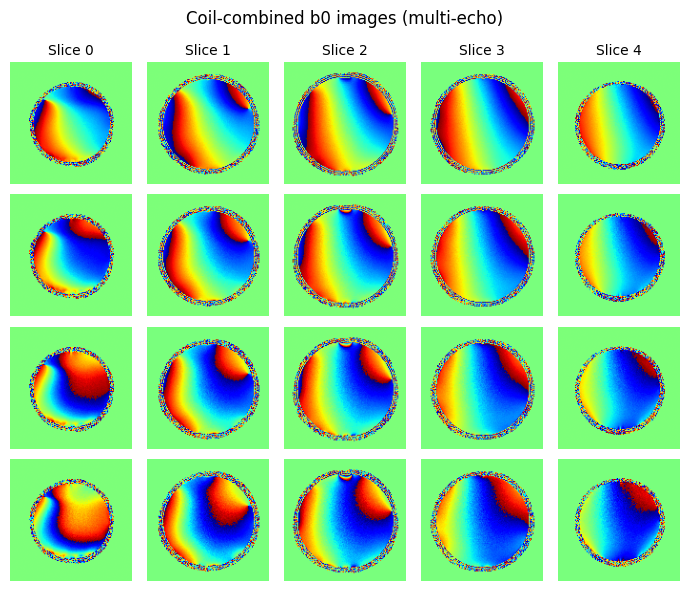

In [31]:
# Coil combine all echoes with sensitivity maps.
den = np.sum(np.abs(sens_maps) ** 2, axis=1) + 1e-8  # (slc, y, x)
num = np.sum(np.conj(sens_maps[:, None, ...]) * b0_img_coils, axis=2)  # (slc, echo, y, x)
b0_img_comb = num / den[:, None, ...]

fig, axes = plt.subplots(n_echo_b0, n_slc_b0, figsize=(7,6), squeeze=False)

for e in range(n_echo_b0):
    for s in range(n_slc_b0):
        ax = axes[e, s]
        ax.imshow(np.angle(b0_img_comb[s, e]), cmap='jet')
        if e == 0:
            ax.set_title(f'Slice {s}', fontsize=10)
        if s == 0:
            ax.set_ylabel(f'Echo {e}', fontsize=10)
        ax.axis('off')
plt.suptitle('Coil-combined b0 images (multi-echo)', fontsize=12)
plt.tight_layout()
plt.show()

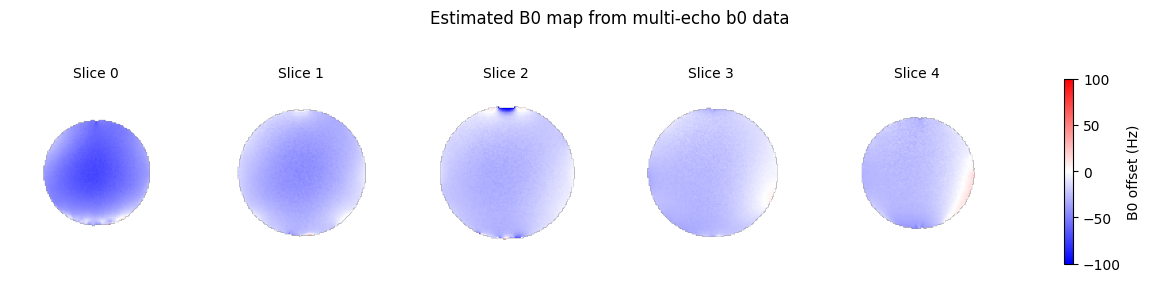

In [32]:
from skimage.restoration import unwrap_phase

# B0 map from linear phase slope over echoes: phi(TE) = phi0 + 2*pi*df*TE
phase_rel = np.angle(b0_img_comb * np.conj(b0_img_comb[:, :1, :, :]))
phase_unw = np.unwrap(phase_rel, axis=1)

te_s = me_timing['te1'] + np.arange(n_echo_b0) * me_timing['echo_spacing']
te_center = te_s - np.mean(te_s)
den_te = np.sum(te_center ** 2) + 1e-12
slope = np.sum(phase_unw * te_center[None, :, None, None], axis=1) / den_te  # rad/s
b0_hz = slope / (2 * np.pi)

# Mask unreliable voxels (low SNR).
mag1 = np.abs(b0_img_comb[:, 0])
mask = mag1 > (0.10 * np.max(mag1, axis=(-2, -1), keepdims=True))
b0_hz_masked = np.where(mask, b0_hz, np.nan)

# Plot B0 map
fig, axes = plt.subplots(1, n_slc_b0, figsize=(16, 4), squeeze=False)
for s in range(n_slc_b0):
    ax = axes[0, s]
    im = ax.imshow(b0_hz_masked[s], cmap='bwr', vmin=-100, vmax=100)
    ax.set_title(f'Slice {s}', fontsize=10)
    ax.axis('off')
fig.suptitle('Estimated B0 map from multi-echo b0 data', fontsize=12, y=0.9)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='B0 offset (Hz)')

In [33]:
# epi_path = r'scan_data\\meas_MID00417_FID15402_tra_msms_fs_se_dti_b2000_pf75_s1_v0_1_0.dat'
# epi_path = r'scan_data\\meas_MID00419_FID15404_tra_msms_fs_se_dti_b2000_33_pf75_s1_v0_1_1.dat'
# epi_path = r'scan_data\\meas_MID00461_FID15446_tra_fs_se_dti_b2000_dir7_pf75_shot1_nav3_v0_1_3.dat'
# epi_path = r'scan_data\\meas_MID00463_FID15448_tra_fs_se_dti_b2000_dir7_pf75_shot1_nav3_v0_1_4.dat'
# epi_path = r'scan_data\\meas_MID00465_FID15450_tra_fs_se_dti_b2000_dir7_pf75_shot1_nav3_v0_1_6.dat'
epi_path = r'scan_data\\meas_MID00043_FID15887_fs_se_dti_b2000_dir7_pf75_shot1_slice5_nav3_v0_1_6.dat'

twix_raw = read_twix(epi_path, parse_pmu=False)
twix_mapped = map_twix(twix_raw)
twix_last = twix_mapped[-1] if isinstance(twix_mapped, list) else twix_mapped

if not isinstance(twix_last, dict) or 'image' not in twix_last:
    raise RuntimeError('TWIX mapped object does not contain image block.')

epi_img_obj = twix_last['image']
epi_data_raw = np.asarray(epi_img_obj[:]).squeeze()
print('Loaded TWIX image shape (raw):', epi_data_raw.shape)

if epi_data_raw.ndim != 6:
    raise RuntimeError(f'Expected 6D image data, got {epi_data_raw.ndim}D: {epi_data_raw.shape}')

# Prefer header-derived map_twix dim labels for robust axis semantics.
epi_axis_map = _infer_axes_from_twix_dims(
    epi_img_obj,
    epi_data_raw.shape,
    role_candidates={
        'dir': ('Seg',),
        'rep': ('Rep',),
        'slc': ('Sli', 'Set'),
        'lin': ('Lin',),
        'ch': ('Cha',),
        'ro': ('Col',),
    },
)

if epi_axis_map is not None:
    perm = [
        epi_axis_map['rep'],
        epi_axis_map['slc'],
        epi_axis_map['dir'],
        epi_axis_map['lin'],
        epi_axis_map['ch'],
        epi_axis_map['ro'],
    ]
    epi_data = np.transpose(epi_data_raw, perm)
    print('Axis reorder from TWIX header dims -> (rep, slc, dir, lin, ch, ro):', perm)
else:
    print('Warning: TWIX dim metadata unavailable; falling back to first-3 shape inference.')

    def _infer_axis_map_first3(shape3, expected):
        axis_map = {}
        used = set()
        for key, size in expected.items():
            matches = [i for i, s in enumerate(shape3) if s == size and i not in used]
            if len(matches) == 1:
                axis_map[key] = matches[0]
                used.add(matches[0])
        return axis_map

    expected = {'rep': int(num_repeats), 'slc': int(n_slices), 'dir': int(num_dirs)}
    axis_map = _infer_axis_map_first3(epi_data_raw.shape[:3], expected)

    if len(axis_map) == 3:
        perm = [axis_map['rep'], axis_map['slc'], axis_map['dir'], 3, 4, 5]
        epi_data = np.transpose(epi_data_raw, perm)
        print('Axis reorder applied -> (rep, slc, dir, lin, ch, ro):', perm)
    else:
        epi_data = epi_data_raw
        print('Warning: axis mapping was ambiguous; keeping raw order.')

print('Canonical image shape:', epi_data.shape)
n_rep, n_slc, n_dir, n_lin_total, n_ch, n_ro = epi_data.shape
print(f'image dims: rep={n_rep}, slc={n_slc}, dir={n_dir}, lin={n_lin_total}, ch={n_ch}, ro={n_ro}')

n_img_lines_expected = int(epi_shots[0].Ny_meas)
n_nav_lines_expected = int(ghost_nav_lines if enable_ghost_nav else 0)

epi_nav = None
if n_nav_lines_expected > 0 and n_lin_total >= (n_nav_lines_expected + n_img_lines_expected):
    epi_nav = epi_data[:, :, :, :n_nav_lines_expected, :, :]
    epi_img = epi_data[:, :, :, n_nav_lines_expected:n_nav_lines_expected + n_img_lines_expected, :, :]
    print(f'Split LIN -> navigator={epi_nav.shape[3]}, imaging={epi_img.shape[3]}')
else:
    epi_img = epi_data[:, :, :, :n_img_lines_expected, :, :]
    if n_nav_lines_expected > 0:
        print('Navigator lines were not split from image block; proceeding with imaging lines only.')

epi_data = epi_img
n_rep, n_slc, n_dir, n_lin, n_ch, n_ro = epi_data.shape
print('Final image-only shape:', epi_data.shape)

Software version: VD/VE (!?)

Scan  0


100%|██████████| 59.8M/59.8M [00:00<00:00, 1.28GB/s]


Scan  1


100%|██████████| 375M/375M [00:00<00:00, 709MB/s]


Loaded TWIX image shape (raw): (7, 2, 5, 96, 32, 216)
Axis reorder from TWIX header dims -> (rep, slc, dir, lin, ch, ro): [1, 2, 0, 3, 4, 5]
Canonical image shape: (2, 5, 7, 96, 32, 216)
image dims: rep=2, slc=5, dir=7, lin=96, ch=32, ro=216
Navigator lines were not split from image block; proceeding with imaging lines only.
Final image-only shape: (2, 5, 7, 96, 32, 216)


In [34]:
from scipy.interpolate import LinearNDInterpolator
from einops import rearrange
import numpy as np

# ---------------------------------------------------------------
# Simplified non-Cartesian -> Cartesian gridding (no EPI ESPIRiT)
# ---------------------------------------------------------------
# Build one-shot imaging ADC trajectory from sequence design
adc_samples_per_echo = int(epi_shots[0].adc_samples)
echoes_per_shot = int(epi_shots[0].Ny_meas)
samples_per_shot = adc_samples_per_echo * echoes_per_shot

traj_adc_start = int((ghost_nav_lines if enable_ghost_nav else 0) * adc_samples_per_echo)
traj_adc_one_shot = k_traj_adc[:2, traj_adc_start:traj_adc_start + samples_per_shot]
traj_pts = traj_adc_one_shot.T  # (points, 2) where col 0 is kx, col 1 is ky

# EPI convention fix: reverse readout direction on odd ky lines
raw_flipped = epi_data.copy()  # (rep, slc, dir, lin, ch, ro)
raw_flipped[:, :, :, 1::2, :, :] = raw_flipped[:, :, :, 1::2, :, ::-1]

# Flatten imaging lines/samples for gridding
raw = rearrange(raw_flipped, 'rep slc d lin ch ro -> rep slc d ch (lin ro)')

# Match trajectory/data length safely
expected_points = n_lin * n_ro
if traj_pts.shape[0] != expected_points:
    print(f'Warning: trajectory points ({traj_pts.shape[0]}) != data points ({expected_points}). Cropping to minimum.')
    p = min(traj_pts.shape[0], expected_points)
    traj_pts = traj_pts[:p]
    raw = raw[..., :p]

# Cartesian target grid (ny/ky first, nx/kx second to match standard orientation)
recon_nx = nx
recon_ny = ny
kmax_x = max(np.max(np.abs(traj_pts[:, 0])), 1e-6)
kmax_y = max(np.max(np.abs(traj_pts[:, 1])), 1e-6)
grid_y, grid_x = np.mgrid[-kmax_y:kmax_y:complex(recon_ny), -kmax_x:kmax_x:complex(recon_nx)]

# Vectorized gridding across rep/slice/dir/channel
data_for_interp = rearrange(raw, 'rep slc d ch pts -> pts rep slc d ch')
interp = LinearNDInterpolator(traj_pts, data_for_interp, fill_value=0)
resampled = interp(grid_x, grid_y)

# Cartesian k-space: (rep, slc, dir, ch, ky, kx)
kspace_cart = rearrange(resampled, 'y x rep slc d ch -> rep slc d ch y x')
print('kspace_cart shape:', kspace_cart.shape)

kspace_cart shape: (2, 5, 7, 32, 128, 128)


In [42]:
# ---------------------------------------------------------------
# PF-POCS + SENSE recon using multi-echo sensitivity maps
# ---------------------------------------------------------------
from scipy.fft import fftshift, ifftshift, ifft2, fft2
import numpy as np

def _fftc2(x):
    return fftshift(fft2(ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))

def _ifftc2(x):
    return fftshift(ifft2(ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))

def _infer_pf_mask_ky(kspace_in):
    ky_energy = np.sum(np.abs(kspace_in), axis=(0, 1, 2, 3, 5))
    if np.max(ky_energy) <= 0:
        raise RuntimeError('Cannot infer ky support from zero k-space energy.')
    ky_has_data = ky_energy > (1e-4 * np.max(ky_energy))
    ky_idx = np.where(ky_has_data)[0]
    if ky_idx.size == 0:
        raise RuntimeError('No acquired ky lines detected.')
    ky_min, ky_max = int(ky_idx.min()), int(ky_idx.max())
    return ky_has_data, ky_min, ky_max

def _pocs_pf_ky_single(ksp2d, ky_has_data, n_iter=8):
    ny, nx = ksp2d.shape
    ky_idx = np.where(ky_has_data)[0]
    ky_min, ky_max = int(ky_idx.min()), int(ky_idx.max())
    ky_c = ny // 2

    left = ky_c - ky_min
    right = ky_max - ky_c
    sym_half = int(max(1, min(left, right)))
    ky_lo = max(0, ky_c - sym_half)
    ky_hi = min(ny, ky_c + sym_half + 1)

    lowres_mask_1d = np.zeros(ny, dtype=bool)
    lowres_mask_1d[ky_lo:ky_hi] = True
    lowres_mask_2d = np.broadcast_to(lowres_mask_1d[:, None], (ny, nx))

    acq_mask_2d = np.broadcast_to(ky_has_data[:, None], (ny, nx))

    img = _ifftc2(ksp2d)
    lowres_img = _ifftc2(ksp2d * lowres_mask_2d)
    phase_prior = np.exp(1j * np.angle(lowres_img + 1e-12))

    for _ in range(n_iter):
        img = np.abs(img) * phase_prior
        ktmp = _fftc2(img)
        ktmp[acq_mask_2d] = ksp2d[acq_mask_2d]
        img = _ifftc2(ktmp)

    ksp_full = _fftc2(img)
    ksp_full[acq_mask_2d] = ksp2d[acq_mask_2d]
    return ksp_full

def _center_crop_or_pad_2d(arr, target_y, target_x):
    out = np.zeros(arr.shape[:-2] + (target_y, target_x), dtype=arr.dtype)
    src_y, src_x = arr.shape[-2], arr.shape[-1]

    copy_y = min(src_y, target_y)
    copy_x = min(src_x, target_x)

    src_y0 = (src_y - copy_y) // 2
    src_x0 = (src_x - copy_x) // 2
    dst_y0 = (target_y - copy_y) // 2
    dst_x0 = (target_x - copy_x) // 2

    out[..., dst_y0:dst_y0 + copy_y, dst_x0:dst_x0 + copy_x] = arr[..., src_y0:src_y0 + copy_y, src_x0:src_x0 + copy_x]
    return out

# Ensure k-space uses shape: (rep, slc, dir, ch, ky, kx)
kspace_in = np.asarray(kspace_cart)
if kspace_in.ndim != 6:
    raise RuntimeError(f'Expected kspace_cart with 6 dims (rep, slc, dir, ch, ky, kx), got {kspace_in.shape}')

n_rep_k, n_slc_k, n_dir_k, n_ch_k, ny_k, nx_k = kspace_in.shape

# Partial Fourier POCS
do_pf = bool(partial_fourier < 0.999)
if do_pf:
    ky_has_data, ky_min, ky_max = _infer_pf_mask_ky(kspace_in)
    ky_span = ky_max - ky_min + 1
    pf_est = ky_span / ny_k
    print(f'PF detect: ky span={ky_span}/{ny_k}, pf_est={pf_est:.3f}, target_pf={partial_fourier:.3f}')

    kspace_pf = np.zeros_like(kspace_in, dtype=np.complex64)
    total_items = n_rep_k * n_slc_k * n_dir_k * n_ch_k
    with tqdm(total=total_items, desc='POCS PF', leave=False) as pbar:
        for rep in range(n_rep_k):
            for slc in range(n_slc_k):
                for d in range(n_dir_k):
                    for ch in range(n_ch_k):
                        kspace_pf[rep, slc, d, ch] = _pocs_pf_ky_single(
                            kspace_in[rep, slc, d, ch],
                            ky_has_data=ky_has_data,
                            n_iter=8,
                        ).astype(np.complex64, copy=False)
                        pbar.update(1)
else:
    kspace_pf = kspace_in.astype(np.complex64, copy=False)
    print('PF skipped (partial_fourier ~ 1.0).')

# Coil images from EPI
img_coils = _ifftc2(kspace_pf)

# Use sensitivity maps computed from multi-echo data in earlier cells.
if 'sens_maps' not in globals():
    raise RuntimeError('Sensitivity maps not found. Run the multi-echo sensitivity/B0 cells first.')

sens_src = np.asarray(sens_maps)
if sens_src.ndim != 4:
    raise RuntimeError(f'Expected sensitivity maps with shape (slc, ch, y, x), got {sens_src.shape}')
if sens_src.shape[0] != n_slc_k or sens_src.shape[1] != n_ch_k:
    raise RuntimeError(f'Sensitivity shape mismatch: sens {sens_src.shape[:2]} vs EPI {(n_slc_k, n_ch_k)}.')

sens_use = sens_src.astype(np.complex64, copy=False)

# Optional padding/cropping in case sensitivity maps were reconstructed at a slightly different resolution
if sens_use.shape[-2:] != (ny_k, nx_k):
    sens_use = _center_crop_or_pad_2d(sens_use, ny_k, nx_k)

# Broadcast per-slice maps across repetitions and diffusion directions
sens_maps_epi = np.broadcast_to(
    sens_use[None, :, None, ...],
    img_coils.shape,
).astype(np.complex64, copy=False)

# SENSE combine: sum(conj(S)*I) / sum(|S|^2)
den = np.sum(np.abs(sens_maps_epi) ** 2, axis=3)
den = np.maximum(den, 1e-10)
img_sense = np.sum(np.conj(sens_maps_epi) * img_coils, axis=3) / den

print('k-space (cartesian) shape (input):', kspace_cart.shape)
print('k-space used for recon (after PF):', kspace_pf.shape)
print('Sensitivity shape:', sens_src.shape)
print('SENSE image shape:', img_sense.shape)

PF detect: ky span=95/128, pf_est=0.742, target_pf=0.750


POCS PF:   0%|          | 0/2240 [00:00<?, ?it/s]

k-space (cartesian) shape (input): (2, 5, 7, 32, 128, 128)
k-space used for recon (after PF): (2, 5, 7, 32, 128, 128)
Sensitivity shape: (5, 32, 128, 128)
SENSE image shape: (2, 5, 7, 128, 128)


In [57]:
import matplotlib.animation as animation
from IPython.display import HTML

# Prefer complex image data for phase display
if 'img_sense' in globals():
    recon_complex = np.asarray(img_sense)
else:
    raise RuntimeError(
        "Complex reconstruction not found. Run SENSE reconstruction cell first so img_sense exists."
    )

# recon_complex expected shape: (rep, slc, dir, x, y)
if recon_complex.ndim != 5:
    raise RuntimeError(
        f"Expected recon with 5 dims (rep, slc, dir, x, y), got {recon_complex.shape}"
    )

# Average along repetition axis
recon_avg = recon_complex.mean(axis=0)  # (slc, dir, x, y)
n_slc_anim = min(5, recon_avg.shape[0])
n_frames = recon_avg.shape[1]

# Direction vectors for left 3D panel
if 'diff_dirs' in globals() and len(diff_dirs) >= n_frames:
    dirs_anim = np.asarray(diff_dirs[:n_frames], dtype=float)
else:
    # Fallback: simple unit-circle traversal in XY plane
    th = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)
    dirs_anim = np.column_stack((np.cos(th), np.sin(th), np.zeros_like(th)))

# Display scaling
mag_data = np.abs(recon_avg[:n_slc_anim])
phase_data = np.angle(recon_avg[:n_slc_anim])
vmax_mag = np.percentile(mag_data, 99.5)
if vmax_mag <= 0:
    vmax_mag = mag_data.max() + 1e-8

fig = plt.figure(figsize=(3.4 * (n_slc_anim + 1), 6.0))
gs = fig.add_gridspec(
    2,
    n_slc_anim + 1,
    width_ratios=[1.8] + [1.0] * n_slc_anim,
    wspace=0.6,
    hspace=0.15,
 )

grad_ax = fig.add_subplot(gs[:, 0], projection='3d')
axes_mag = [fig.add_subplot(gs[0, s + 1]) for s in range(n_slc_anim)]
axes_ph = [fig.add_subplot(gs[1, s + 1]) for s in range(n_slc_anim)]
plt.close(fig)  # Prevent duplicate static display

ims_mag = []
ims_ph = []

# Assuming 'fov' is configured in meters
fov_mm = (fov * 1000.0) if 'fov' in globals() else 220.0
# For the un-transposed array, (row, col) = (PE, RO)
# Extent corresponds to [left(RO), right(RO), bottom(PE), top(PE)]
extent = [-fov_mm / 2, fov_mm / 2, fov_mm / 2, -fov_mm / 2]

for s in range(n_slc_anim):
    im_m = axes_mag[s].imshow(
        np.abs(recon_avg[s, 0]), 
        cmap='gray', 
        vmin=0, 
        vmax=vmax_mag,
        extent=extent
    )
    axes_mag[s].set_title(f'Slice {s} Mag')
    axes_mag[s].set_xlabel('RO (mm)')
    if s == 0:
        axes_mag[s].set_ylabel('PE (mm)')
    else:
        # Hide y-ticks for non-first columns to keep it clean
        axes_mag[s].set_yticklabels([])

    im_p = axes_ph[s].imshow(
        np.angle(recon_avg[s, 0]), 
        cmap='jet', 
        vmin=-np.pi, 
        vmax=np.pi,
        extent=extent
    )
    axes_ph[s].set_title(f'Slice {s} Phase')
    axes_ph[s].set_xlabel('RO (mm)')
    if s == 0:
        axes_ph[s].set_ylabel('PE (mm)')
    else:
        axes_ph[s].set_yticklabels([])

    ims_mag.append(im_m)
    ims_ph.append(im_p)

# Draw context sphere once for limits reference
u = np.linspace(0, 2 * np.pi, 24)
v = np.linspace(0, np.pi, 24)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones(np.size(u)), np.cos(v))

def draw_direction(ax, g, frame):
    ax.cla()
    ax.quiver(0, 0, 0, g[0], g[1], g[2], color='crimson', linewidth=3, arrow_length_ratio=0.15)
    ax.plot_wireframe(X, Y, Z, color='k', alpha=0.12)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_xlabel('Gx')
    ax.set_ylabel('Gy')
    ax.set_zlabel('Gz')
    dlabel = dir_labels[frame] if 'dir_labels' in globals() and frame < len(dir_labels) else f'dir {frame}'
    ax.set_title(f'Diffusion Direction\n{dlabel}')

# Initial direction
draw_direction(grad_ax, dirs_anim[0], 0)
fig.suptitle('Rep-averaged SENSE recon: magnitude + phase across 5 slices', fontsize=13)
fig.tight_layout(rect=[0, 0, 1.0, 0.90])

def update(frame):
    for s in range(n_slc_anim):
        ims_mag[s].set_data(np.abs(recon_avg[s, frame]))
        ims_ph[s].set_data(np.angle(recon_avg[s, frame]))
        dlabel = dir_labels[frame] if 'dir_labels' in globals() and frame < len(dir_labels) else f'dir {frame}'
        axes_mag[s].set_title(f'Slice {s} Mag, {dlabel}')
        axes_ph[s].set_title(f'Slice {s} Phase, {dlabel}')

    draw_direction(grad_ax, dirs_anim[frame], frame)
    return ims_mag + ims_ph

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=250,
    blit=False,
    repeat=True,
    repeat_delay=200,
 )

HTML(ani.to_jshtml())